# News Categorization NLP - Modeling

Here we will prepare the data for modeling and test and evaluate our models.

# Import Base Modules


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
gpu_info = !nvidia-smi
gpu_info = '\n'.join(gpu_info)
if gpu_info.find('failed') >= 0:
  print('Not connected to a GPU')
else:
  print(gpu_info)

zsh:1: command not found: nvidia-smi


# Load & Prepare Data

In [10]:
# Load data
df = pd.read_csv('news_data_processed.csv')
df.head()

,link,category,authors,date,description,language
0,https://www.huffpost.com/entry/covid-boosters-...,News,"Carla K. Johnson, AP",2022-09-23,"['million', 'americans', 'roll', 'sleeve', 'om...",en
1,https://www.huffpost.com/entry/american-airlin...,News,Mary Papenfuss,2022-09-23,"['american', 'airlines', 'flyer', 'charge', 'b...",en
2,https://www.huffpost.com/entry/funniest-tweets...,Entertainment,Elyse Wanshel,2022-09-23,"['funniest', 'tweet', 'cat', 'dog', 'week', 's...",en
3,https://www.huffpost.com/entry/funniest-parent...,Lifestyle,Caroline Bologna,2022-09-23,"['funniest', 'tweet', 'parent', 'week', 'sept'...",en
4,https://www.huffpost.com/entry/amy-cooper-lose...,News,Nina Golgowski,2022-09-22,"['woman', 'call', 'cop', 'black', 'birdwatcher...",en


We'll remove the link, date, and language as these categories won't be useful for our model (every language is now set to en)

In [11]:
df.drop(columns=['link', 'date', 'language'], inplace=True)
df.head()

,category,authors,description
0,News,"Carla K. Johnson, AP","['million', 'americans', 'roll', 'sleeve', 'om..."
1,News,Mary Papenfuss,"['american', 'airlines', 'flyer', 'charge', 'b..."
2,Entertainment,Elyse Wanshel,"['funniest', 'tweet', 'cat', 'dog', 'week', 's..."
3,Lifestyle,Caroline Bologna,"['funniest', 'tweet', 'parent', 'week', 'sept'..."
4,News,Nina Golgowski,"['woman', 'call', 'cop', 'black', 'birdwatcher..."


In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 189803 entries, 0 to 189802
Data columns (total 3 columns):
 #   Column       Non-Null Count   Dtype
---  ------       --------------   -----
 0   category     189803 non-null  str  
 1   authors      156861 non-null  str  
 2   description  189803 non-null  str  
dtypes: str(3)
memory usage: 4.3 MB


There are a few null values in our authors column. We will impute this with 'None' so we don't lose data.

In [13]:
# Impute null authors
df['authors'].fillna('None', inplace=True)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 189803 entries, 0 to 189802
Data columns (total 3 columns):
 #   Column       Non-Null Count   Dtype
---  ------       --------------   -----
 0   category     189803 non-null  str  
 1   authors      156861 non-null  str  
 2   description  189803 non-null  str  
dtypes: str(3)
memory usage: 4.3 MB


/var/folders/95/yr6zk14d0rb52tgyfy426wwh0000gn/T/ipykernel_21179/3102458301.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['authors'].fillna('None', inplace=True)


# Encoding variables

We'll use TF-IDF for the description column as this will weight words based on frequency and work well with ML models.

In [14]:
# Import tfidf
from sklearn.feature_extraction.text import TfidfVectorizer

# Instantiate & fit to description
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1,2), min_df=5) #capturing bigrams will improve performance
tfidf_desc = tfidf.fit_transform(df['description'])

We also have to handle both categories and authors. I'll use TargetEncoder to handle the high cardinality of the Authors column and I'll use LabelEncoder to assign an integer to each category.

In [15]:
%pip install category_encoders


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [16]:
# Import encoders
from category_encoders import TargetEncoder
from sklearn.preprocessing import LabelEncoder

# Instantiate & fit to authors
target = TargetEncoder(cols='authors')
authors = target.fit_transform(df['authors'], df['category'])

In [17]:
# Instantiate & fit to categories
label = LabelEncoder()
y = label.fit_transform(df['category']) #saving as dependent variable

Now we'll have to create the X variable with both the encoded description & authors columns

In [18]:
from scipy.sparse import hstack, csr_matrix

# Convert authors array to a sparse matrix
authors_sparse = csr_matrix(authors.values.reshape(-1, 1))

# Horizontally stack the sparse matrices
X = hstack([tfidf_desc, authors_sparse])

# Display the shape and type of the new sparse matrix
print("Shape of X:", X.shape)
print("Type of X:", type(X))

Shape of X: (189803, 10001)
Type of X: <class 'scipy.sparse._csr.csr_matrix'>


# Split to train/test sets

In [19]:
# Split into train/test
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Modeling

Before modeling, I'll import classification report and confusions matrix for our evaluation metrics

In [20]:
# Import classification report
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

## Logistic Regression

We'll start with logistic regression as this is a good model to weight our descriptions for each category.

In [21]:
# Import logistic regression
from sklearn.linear_model import LogisticRegression

# Instantiate model
lr = LogisticRegression()

In [22]:
# Fit on training data
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Now lets evaluate how the model performed

In [23]:
# Evaluate model
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.78      0.53      0.63      4044
           1       0.69      0.38      0.49      1994
           2       0.66      0.72      0.69      5492
           3       0.76      0.81      0.78      7998
           4       0.76      0.83      0.79     12797
           5       0.75      0.86      0.80     11914
           6       0.68      0.27      0.39      2095
           7       0.84      0.39      0.54      1117

    accuracy                           0.74     47451
   macro avg       0.74      0.60      0.64     47451
weighted avg       0.74      0.74      0.73     47451



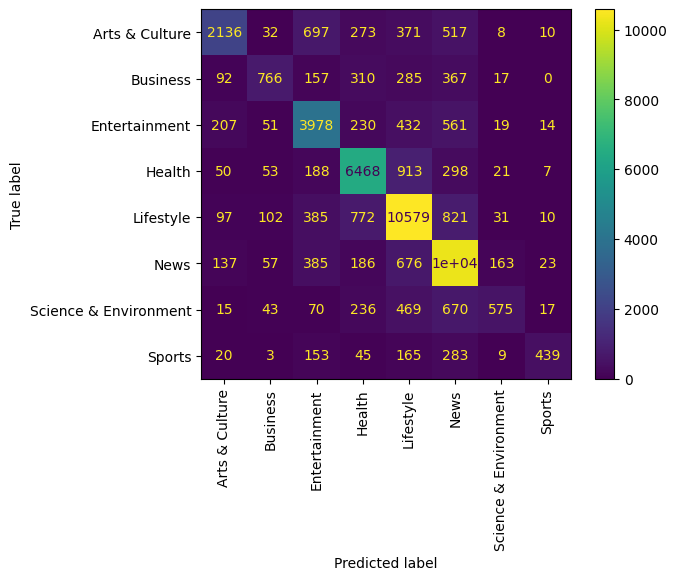

In [24]:
# Visualize confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label.classes_)
disp.plot()
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

The 75% accuracy is good but we would want to improve the macro f1 score so all categories are seeing accuracy as the model heavily caters to the larger categories right now.

We'll use GridSearchCV to find the best params.

In [25]:
# Import GridSearchCV
from sklearn.model_selection import GridSearchCV

# Test params
param_grid = {
        'C': [0.01, 0.1, 1, 10],
        'class_weight': [None, 'balanced'],
        'max_iter': [1000]
    }

grid = GridSearchCV(lr, param_grid, cv=3, scoring='f1_macro', n_jobs=-1)
lr_grid = grid.fit(X_train, y_train)

# Results
print('Best hyperparameters are: '+str(lr_grid.best_params_))
print('Best score is: '+str(lr_grid.best_score_))

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:

Best hyperparameters are: {'C': 1, 'class_weight': None, 'max_iter': 1000}
Best score is: 0.6954682344434912


It seems this actually may have performed worse than no parameters at all. We'll take a look at the model.

In [26]:
lr = LogisticRegression(C=1, max_iter=1000, class_weight=None)
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

In [27]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.75      0.64      0.69      4044
           1       0.70      0.50      0.58      1994
           2       0.74      0.71      0.73      5492
           3       0.79      0.83      0.81      7998
           4       0.77      0.85      0.81     12797
           5       0.80      0.85      0.83     11914
           6       0.67      0.40      0.50      2095
           7       0.81      0.62      0.70      1117

    accuracy                           0.77     47451
   macro avg       0.75      0.68      0.71     47451
weighted avg       0.77      0.77      0.77     47451



We see good improvement here in both the macro avg and weighted average but still less than desired. Accuracy is at 77% when we are shooting for about 80-85%.

We'll visualize this in a confusion matrix

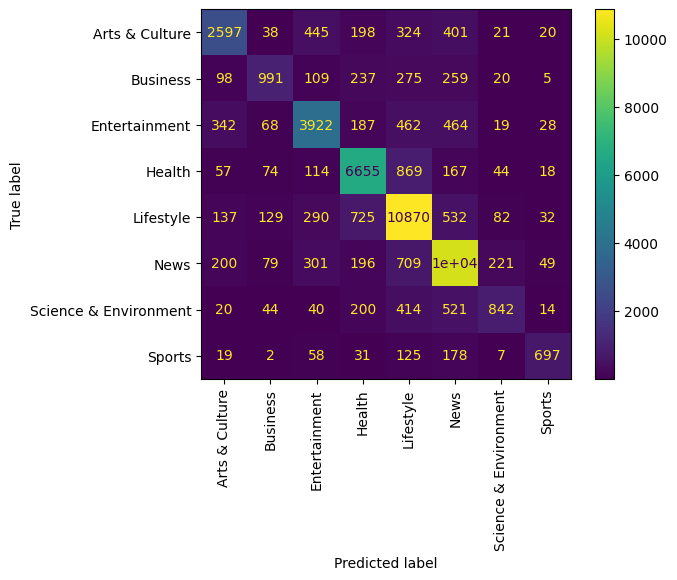

In [28]:
# Visualize confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label.classes_)
disp.plot()
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

We can see that the results across the board are pretty dispersed. While nearly every column has a majority correct, we are still seeing a lot of disparity in certain categories such as Science & Environment.

We'll test out other models to see if we can get closer to desired accuracy.

## Multinomial Naive Bayes

First, I'll try Naive Bayes as this will use probability to see which category has the highest probability of being correct.

In [29]:
# Import naive bayes
from sklearn.naive_bayes import MultinomialNB

# Instantiate model
nb = MultinomialNB()
nb.fit(X_train, y_train)
y_pred = nb.predict(X_test)

In [30]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.82      0.39      0.53      4044
           1       0.68      0.22      0.33      1994
           2       0.72      0.58      0.64      5492
           3       0.74      0.77      0.76      7998
           4       0.65      0.83      0.73     12797
           5       0.70      0.87      0.77     11914
           6       0.72      0.21      0.32      2095
           7       0.79      0.31      0.45      1117

    accuracy                           0.70     47451
   macro avg       0.73      0.52      0.57     47451
weighted avg       0.71      0.70      0.68     47451



We see 70% overall accuracy with this model but the macro avg is much lower than the weighted f1 avg showing the model is good on the bigger categories but worse on the smaller ones.

Let's look at the confusion matrix for this

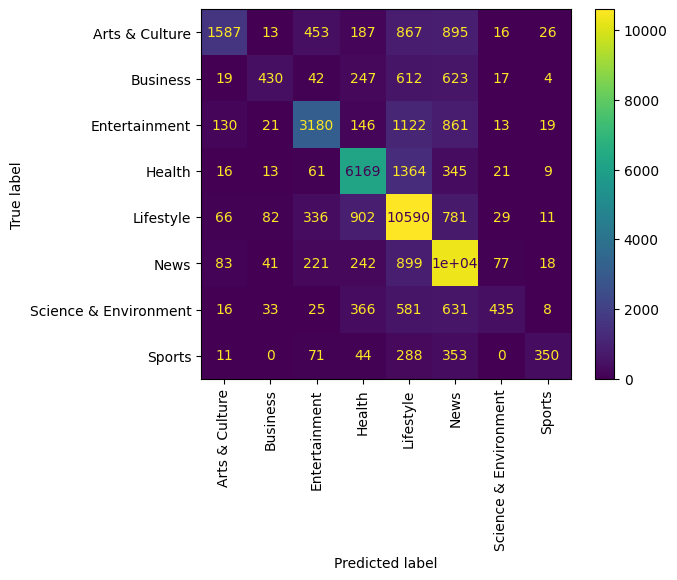

In [31]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label.classes_)
disp.plot()
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

So it is performing well for the larger categories but for smaller categories it's nearly ignoring them. We'll tune the parameters using GridSearchCV to find the best parameters

In [32]:
# Test for params
param_grid = {
    'alpha': [0.01, 0.1, 1.0, 10.0],
    'fit_prior': [True, False]
}

grid = GridSearchCV(nb, param_grid, cv=5, scoring='f1_macro', n_jobs=-1)
nb_grid = grid.fit(X_train, y_train)

# Results
print('Best hyperparameters are: '+str(nb_grid.best_params_))
print('Best score is: '+str(nb_grid.best_score_))

Best hyperparameters are: {'alpha': 1.0, 'fit_prior': False}
Best score is: 0.6465495956699137


The score is still a little lower than desired but let's look deeper at how this model performs with these parameters.

In [33]:
# Instantiate & Fit w/ new params
nb = MultinomialNB(alpha=0.1, fit_prior=False)
nb.fit(X_train, y_train)
y_pred = nb.predict(X_test)

In [34]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.59      0.62      0.61      4044
           1       0.38      0.66      0.48      1994
           2       0.66      0.68      0.67      5492
           3       0.74      0.78      0.76      7998
           4       0.83      0.64      0.72     12797
           5       0.84      0.71      0.77     11914
           6       0.34      0.62      0.44      2095
           7       0.48      0.84      0.61      1117

    accuracy                           0.69     47451
   macro avg       0.61      0.69      0.63     47451
weighted avg       0.73      0.69      0.70     47451



We do see a better macro average but our overall accuracy dipped. Smaller categories saw a much larger difference than the larger categories. This has been overall the worst performing model in accuracy though.

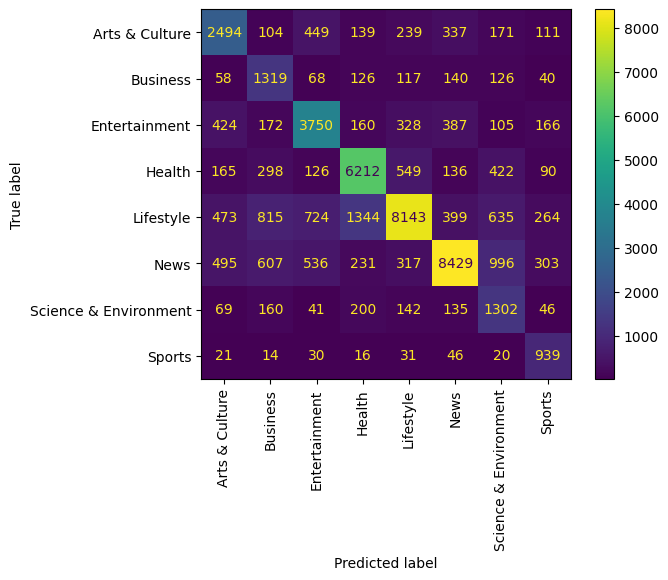

In [35]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label.classes_)
disp.plot()
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

This is good for some categories but still lags behind the accuracy we desire. We'll try a linear SVM

## LightGBM

We'll try Light GBM as this will build a decision tree like structure to see if this will yield better results

In [36]:
# Import LightGBM
import lightgbm as lgb

# Instantiate model
lgbm = lgb.LGBMClassifier()
lgbm.fit(X_train, y_train)
y_pred = lgbm.predict(X_test)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 33.546361 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 562596
[LightGBM] [Info] Number of data points in the train set: 142352, number of used features: 10000
[LightGBM] [Info] Start training from score -2.481512
[LightGBM] [Info] Start training from score -3.143641
[LightGBM] [Info] Start training from score -2.165421
[LightGBM] [Info] Start training from score -1.802239
[LightGBM] [Info] Start training from score -1.304196
[LightGBM] [Info] Start training from score -1.366678
[LightGBM] [Info] Start training from score -3.120774
[LightGBM] [Info] Start training from score -3.765290


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [37]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.75      0.79      4044
           1       0.76      0.63      0.69      1994
           2       0.78      0.76      0.77      5492
           3       0.83      0.88      0.85      7998
           4       0.85      0.89      0.87     12797
           5       0.84      0.88      0.86     11914
           6       0.83      0.59      0.69      2095
           7       0.80      0.70      0.74      1117

    accuracy                           0.83     47451
   macro avg       0.82      0.76      0.78     47451
weighted avg       0.83      0.83      0.83     47451



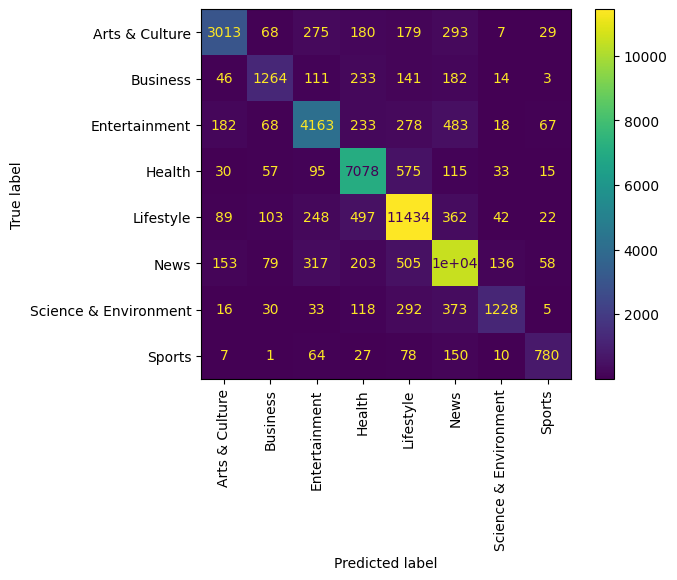

In [38]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label.classes_)
disp.plot()
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

This is great as we reached our goal of 80-85%! Across almost all categories we also see 75%+ accuracy other than Science & environment and Business. We'll see if we can improve this at all by tuning the hyperparameters. We'll use optuna to optimize this process.

In [ ]:
# Install optuna
%pip install optuna


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [46]:
import optuna
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
import warnings
import os

warnings.filterwarnings('ignore', category=UserWarning)

# Efficiency knobs - use a lighter Optuna search to find a strong region quickly
NUM_PARALLEL_TRIALS = 1
CORES_PER_TRIAL = max(1, (os.cpu_count() or 2) // 2)

print(f"Optuna parallel trials={NUM_PARALLEL_TRIALS}, cores/trial={CORES_PER_TRIAL}")

# Use the existing train split. We will perform CV on X_train only and keep X_test untouched.
X_t = X_train
y_t = y_train

def objective(trial):
    params = {
        'objective': 'multiclass',
        'num_class': int(len(np.unique(y_t))),
        'num_leaves': trial.suggest_int('num_leaves', 32, 128),
        'max_depth': trial.suggest_int('max_depth', 4, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'n_jobs': CORES_PER_TRIAL,
        'verbose': -1,
    }

    def macro_f1_eval(y_pred, dataset):
        y_true = dataset.get_label().astype(int)
        y_pred = y_pred.reshape(params['num_class'], -1).argmax(axis=0)
        return 'f1_macro', f1_score(y_true, y_pred, average='macro'), True

    skf = StratifiedKFold(n_splits=2, shuffle=True, random_state=42)
    fold_scores = []

    for train_idx, val_idx in skf.split(X_t, y_t):
        X_tr, X_val = X_t[train_idx], X_t[val_idx]
        y_tr, y_val = y_t[train_idx], y_t[val_idx]

        dtrain = lgb.Dataset(X_tr, label=y_tr)
        dval = lgb.Dataset(X_val, label=y_val, reference=dtrain)

        bst = lgb.train(
            params,
            dtrain,
            num_boost_round=500,
            valid_sets=[dval],
            feval=macro_f1_eval,
            callbacks=[lgb.early_stopping(30)],
            verbose_eval=False,
        )

        preds = bst.predict(X_val, num_iteration=bst.best_iteration)
        preds_labels = np.argmax(preds, axis=1)
        fold_scores.append(f1_score(y_val, preds_labels, average='macro'))

    return float(np.mean(fold_scores))

study = optuna.create_study(direction='maximize')

try:
    study.optimize(objective, n_trials=15, n_jobs=NUM_PARALLEL_TRIALS)
except KeyboardInterrupt:
    print("Study interrupted by user.")

# Ensure at least one trial completed before accessing best params
completed = [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE]
if not completed:
    print("No completed trials.")
else:
    print('Best params:', study.best_params)
print('Best score:', study.best_value)


[I 2026-06-05 23:40:09,084] A new study created in memory with name: no-name-597ebfc3-257f-4ea1-a882-88eccad19d9b


Optuna parallel trials=2, cores/trial=2


/var/folders/95/yr6zk14d0rb52tgyfy426wwh0000gn/T/ipykernel_21179/4019082093.py:26: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 1e-3, 0.2),


Training until validation scores don't improve for 50 rounds
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[17]	valid_0's multi_logloss: 1.53582	valid_0's f1_macro: 0.109295
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[3]	valid_0's multi_logloss: 1.79361	valid_0's f1_macro: 0.109438
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[42]	valid_0's multi_logloss: 1.31926	valid_0's f1_macro: 0.108048


[I 2026-06-05 23:45:20,716] Trial 0 finished with value: 0.4335052612254601 and parameters: {'num_leaves': 109, 'max_depth': 4, 'learning_rate': 0.010329645091780462, 'subsample': 0.8711880849804976, 'colsample_bytree': 0.9749211246720962}. Best is trial 0 with value: 0.4335052612254601.
/var/folders/95/yr6zk14d0rb52tgyfy426wwh0000gn/T/ipykernel_21179/4019082093.py:26: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 1e-3, 0.2),


...

Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[41]	valid_0's multi_logloss: 0.693233	valid_0's f1_macro: 0.108424


[I 2026-06-06 00:44:56,232] Trial 29 finished with value: 0.6973170289909733 and parameters: {'num_leaves': 116, 'max_depth': 11, 'learning_rate': 0.07444076220025973, 'subsample': 0.607830068390865, 'colsample_bytree': 0.8105117586937547}. Best is trial 28 with value: 0.72371728968391.
/var/folders/95/yr6zk14d0rb52tgyfy426wwh0000gn/T/ipykernel_21179/4019082093.py:26: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  'learning_rate': trial.suggest_loguniform('learning_rate', 1e-3, 0.2),


Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[13]	valid_0's multi_logloss: 0.89814	valid_0's f1_macro: 0.109658
Training until validation scores don't improve for 50 rounds
Study interrupted by user.
Best params: {'num_leaves': 65, 'max_depth': 11, 'learning_rate': 0.1840285948185988, 'subsample': 0.6050262660651631, 'colsample_bytree': 0.8588298354197473}
Best score: 0.72371728968391


[W 2026-06-06 00:54:00,238] Trial 30 failed with parameters: {'num_leaves': 113, 'max_depth': 11, 'learning_rate': 0.08151975610926902, 'subsample': 0.6031540595609135, 'colsample_bytree': 0.8182978628428691} because of the following error: ZMQError('Socket operation on non-socket').
Traceback (most recent call last):
  File "/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/var/folders/95/yr6zk14d0rb52tgyfy426wwh0000gn/T/ipykernel_21179/4019082093.py", line 50, in objective
    bst = lgb.train(
          ^^^^^^^^^^
  File "/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/lightgbm/engine.py", line 332, in train
    cb(
  File "/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/lightgbm/callback.py", line 435, in __call__
    _log_info(f"Early stopping, best iteration is:

Early stopping, best iteration is:
[2]	valid_0's multi_logloss: 1.44164	valid_0's f1_macro: 0.108558Did not meet early stopping. Best iteration is:
[100]	valid_0's multi_logloss: 0.673295	valid_0's f1_macro: 0.108406


In [47]:
# Fit lgb model with best params
lgbm = lgb.LGBMClassifier(objective="multiclass",
                          num_class=len(set(y_train)),
                          random_state=42,
                          n_jobs=-1,
                          num_leaves= 198,
                          max_depth= -1,
                          learning_rate=0.18869582824804135,
                          subsample=0.8759715710736063,
                          colsample_bytree= 0.6194241457994509)

lgbm.fit(X_train, y_train)
y_pred = lgbm.predict(X_test)

Training until validation scores don't improve for 50 rounds
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 54.987230 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 562596
[LightGBM] [Info] Number of data points in the train set: 142352, number of used features: 10000
[LightGBM] [Info] Start training from score -2.481512
[LightGBM] [Info] Start training from score -3.143641
[LightGBM] [Info] Start training from score -2.165421
[LightGBM] [Info] Start training from score -1.802239
[LightGBM] [Info] Start training from score -1.304196
[LightGBM] [Info] Start training from score -1.366678
[LightGBM] [Info] Start training from score -3.120774
[LightGBM] [Info] Start training from score -3.765290
Early stopping, best iteration is:
[2]	valid_0's multi_logloss: 1.6476	valid_0's f1_macro: 0.108806
[LightGBM] [Warning] Detected that num_threads changed during training (from 2 to 4), it may cause unexpected e

[I 2026-06-06 00:59:21,851] Trial 31 finished with value: 0.44913902558146557 and parameters: {'num_leaves': 52, 'max_depth': 10, 'learning_rate': 0.03864209860277455, 'subsample': 0.636772087317506, 'colsample_bytree': 0.7252032485401336}. Best is trial 28 with value: 0.72371728968391.


In [48]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.76      0.80      4044
           1       0.78      0.64      0.70      1994
           2       0.81      0.79      0.80      5492
           3       0.86      0.90      0.88      7998
           4       0.87      0.91      0.89     12797
           5       0.84      0.90      0.87     11914
           6       0.83      0.62      0.71      2095
           7       0.84      0.67      0.75      1117

    accuracy                           0.85     47451
   macro avg       0.84      0.77      0.80     47451
weighted avg       0.85      0.85      0.85     47451



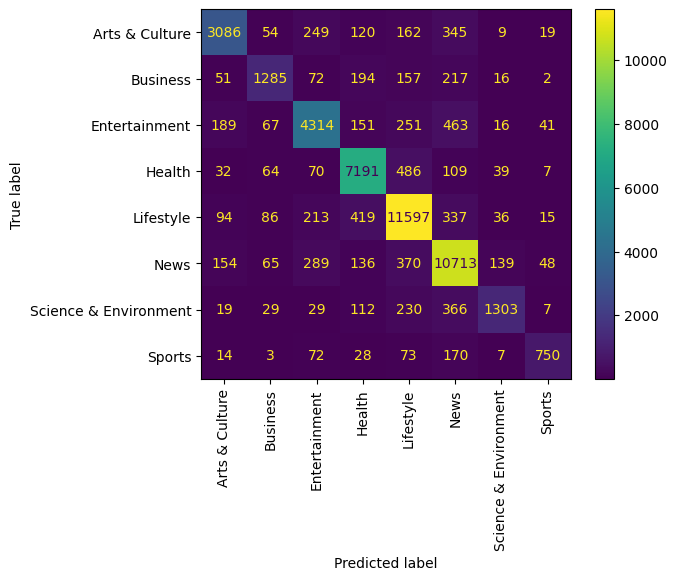

In [49]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label.classes_)
disp.plot()
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.show()

These are great results and a model that we can use for new classification. The model had 85% total accuracy, only one category below 70% F1 score, and 80% macro F1 average. The only category below 70% was business which we can see in the confuxion matrix had a lot of overlap with news which makes sense.

Next, I'll bootstrap our dataset to ensure the accuracy and F1 scores show our model is stable

In [50]:
from sklearn.metrics import accuracy_score, f1_score
import time

n_iterations = 50
n_estimators = 25
max_depth = 6

# Split off 20k rows for evaluation
eval_idx = np.random.choice(X.shape[0], size=20000, replace=False)
X_eval, y_eval = X[eval_idx], y[eval_idx]

results = []
t0 = time.perf_counter()
for i in range(n_iterations):
    rng = np.random.RandomState(i)
    boot_idx = rng.choice(X.shape[0], size=int(0.5*X.shape[0]), replace=True)
    X_boot, y_boot = X[boot_idx], y[boot_idx]
    # Lighter version of LGBM for bootstrapping
    model = lgb.LGBMClassifier(objective='multiclass',
                               num_class=len(set(y_train)),
                               n_estimators=n_estimators,  # Reduced number of estimators
                               n_jobs=1,
                               random_state=42,
                               num_leaves= 198,
                               max_depth=max_depth,
                               learning_rate=0.18869582824804135,
                               subsample=0.8759715710736063,
                               colsample_bytree= 0.6194241457994509,
                               verbose=-1)
    model.fit(X_boot, y_boot)

    preds = model.predict(X_eval)
    acc = accuracy_score(y_eval, preds)
    f1  = f1_score(y_eval, preds, average="macro")
    results.append((acc, f1))

t1 = time.perf_counter()
print(f"{n_iterations} iterations finished in {t1 - t0:.1f} sec")

accs, f1s = zip(*results)

# Mean and Std
print(f"Mean Accuracy: {np.mean(accs):.4f} ± {np.std(accs):.4f}")
print(f"Mean Macro-F1: {np.mean(f1s):.4f} ± {np.std(f1s):.4f}")

# 95% Confidence Intervals
acc_ci = np.percentile(accs, [2.5, 97.5])
f1_ci  = np.percentile(f1s, [2.5, 97.5])

print(f"Accuracy 95% CI: [{acc_ci[0]:.4f}, {acc_ci[1]:.4f}]")
print(f"Macro-F1 95% CI: [{f1_ci[0]:.4f}, {f1_ci[1]:.4f}]")

50 iterations finished in 3165.9 sec
Mean Accuracy: 0.7870 ± 0.0017
Mean Macro-F1: 0.7331 ± 0.0025
Accuracy 95% CI: [0.7841, 0.7898]
Macro-F1 95% CI: [0.7293, 0.7373]


The bootstrapping shows the model is accurate and stable. These results are statistically reliable that we would get at around 78% accuracy with any subset of data. This proves that this model is the right choice for our categorization.

# Conclusion

The LGBM model has shown strong performance in the news categorization project, achieving a mean accuracy of 85% and a mean macro-F1 score of 80%. These metrics indicate a reliable and balanced model, effectively distinguishing between classes.

Given its high performance and computational efficiency, LightGBM is a suitable choice for this classification problem, balancing predictive accuracy with resource usage. We can use this model to effectively classify news articles going forward and make recommendations on other news articles for readers.